<a href="https://colab.research.google.com/github/Drankenstain/portofolio/blob/main/Spark_SQL_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from pyspark.sql.functions import *
from pyspark.sql import SparkSession
from matplotlib import pyplot as plt
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator

In [ ]:
spark = SparkSession.builder.getOrCreate()

In [ ]:
# Import Dataset
MsStaff = spark.read.csv("MsStaff.csv", header=True, inferSchema=True)
MsSkateBoard = spark.read.csv("MsSkateBoard.csv", header=True, inferSchema=True)
MsCustomer = spark.read.csv("MsCustomer.csv", header=True, inferSchema=True)
SkateBoardCategory = spark.read.csv("SkateBoardCategory.csv", header=True, inferSchema=True)
DetailTransaction = spark.read.csv("DetailTransaction.csv", header=True, inferSchema=True)
HeaderTransaction = spark.read.csv("HeaderTransaction.csv", header=True, inferSchema=True)

In [ ]:
# Register Table
MsStaff.registerTempTable("MsStaff")
MsSkateBoard.registerTempTable("MsSkateBoard")
MsCustomer.registerTempTable("MsCustomer")
SkateBoardCategory.registerTempTable("SkateBoardCategory")
DetailTransaction.registerTempTable("DetailTransaction")
HeaderTransaction.registerTempTable("HeaderTransaction")

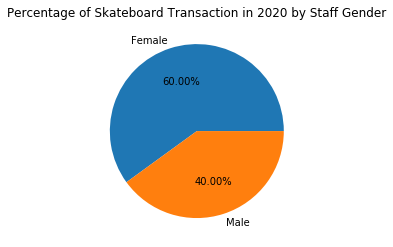

+-----------------+-----------+
|Total Transaction|StaffGender|
+-----------------+-----------+
|               36|     Female|
|               24|       Male|
+-----------------+-----------+



In [ ]:
#a.	Show the percentage of Skateboard transactions by staff gender that happened in 2020 using a pie plot.
result = spark.sql("""
    SELECT COUNT(TransactionID) AS `Total Transaction`, StaffGender
    FROM HeaderTransaction th
    JOIN MsStaff ms ON th.StaffID = ms.StaffID
    WHERE YEAR(TransactionDate) = 2020
    GROUP BY StaffGender
""")

pd_result = result.toPandas()

plt.pie(pd_result["Total Transaction"], labels=pd_result["StaffGender"], autopct="%1.2f%%")
plt.title("Percentage of Skateboard Transaction in 2020 by Staff Gender")
plt.show()
result.show()

+-----+---------------+
|Month|Number of Sales|
+-----+---------------+
|    1|             13|
|    2|             21|
|    3|             27|
|    4|              4|
|    5|             54|
|    6|             18|
|    7|             32|
|    8|              8|
|    9|             62|
|   10|             19|
+-----+---------------+



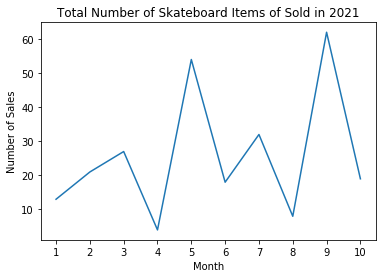

In [ ]:
#b.	Show the total number of skateboards sold each month in 2021 using a line plot.
result = spark.sql("""
    SELECT MONTH(TransactionDate) AS `Month`, SUM(Quantity) AS `Number of Sales`
    FROM HeaderTransaction th
    JOIN DetailTransaction td ON th.TransactionID = td.TransactionID
    WHERE YEAR(TransactionDate) = 2021
    GROUP BY Month
    ORDER BY Month
""")

result.show()

pd_result = result.toPandas()
plt.plot(pd_result["Month"], pd_result["Number of Sales"])
plt.xticks(pd_result["Month"])
plt.title("Total Number of Skateboard Items of Sold in 2021")
plt.xlabel("Month")
plt.ylabel("Number of Sales")
plt.show()

+---------+---------------+
|Frequency| SkateBoardRate|
+---------+---------------+
|        2|Semi-Profitable|
|        2|     Profitable|
|        1| Non-Profitable|
+---------+---------------+



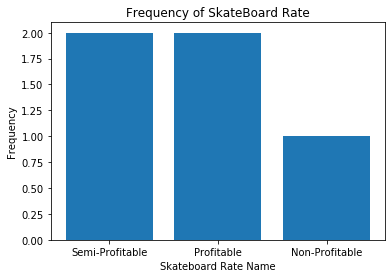

In [ ]:
# c.	Show the frequency of skateboard rate by skateboard category for 2020 using a bar plot. The skateboard rate is determined based on the following condition.

result = spark.sql("""
    SELECT COUNT(Total) AS `Frequency`, SkateBoardRate
    FROM (SELECT SUM(Quantity) AS `Total`,
    CASE
        WHEN SUM(Quantity) > 80 THEN 'Profitable'
        WHEN SUM(Quantity) BETWEEN 71 AND 80 THEN 'Semi-Profitable'
        WHEN SUM(Quantity) <= 70 THEN 'Non-Profitable'
    END AS SkateBoardRate
    FROM HeaderTransaction th
    JOIN DetailTransaction td ON th.TransactionID = td.TransactionID
    JOIN MsSkateBoard msb ON msb.SkateBoardID = td.SkateBoardID
    JOIN SkateBoardCategory sbc ON sbc.CategoryID = msb.CategoryID
    WHERE YEAR(TransactionDate) = 2020
    GROUP BY sbc.CategoryID) AS aliastable
    GROUP BY SkateBoardRate
""")

result.show()

pd_result = result.toPandas()
plt.bar(pd_result["SkateBoardRate"], pd_result["Frequency"])
# plt.xticks(pd_result["SkateBoardRate"])
plt.title("Frequency of SkateBoard Rate")
plt.xlabel("Skateboard Rate Name")
plt.ylabel("Frequency")
plt.show()

In [ ]:
#Classification Model

In [ ]:
df_train = spark.read.csv("BigFootTraining.csv", header=True, inferSchema=True)
df_test = spark.read.csv("BigFootTesting.csv", header=True, inferSchema=True)

In [ ]:
df_train = df_train.na.drop()
df_test = df_test.na.drop()

In [ ]:
df_train = df_train.select("height","weight", "prehistoric")
df_test = df_test.select("height","weight", "prehistoric")

In [ ]:
df_train = df_train.withColumn("prehistoric",
                              when(df_train["prehistoric"] == "TRUE", 1)
                              .when(df_train["prehistoric"] == "FALSE", 0)
                              )

df_test = df_test.withColumn("prehistoric",
                              when(df_test["prehistoric"] == "TRUE", 1)
                              .when(df_test["prehistoric"] == "FALSE", 0)
                              )
#train transform
df_train = df_train.withColumn("height", regexp_replace(col("height"), " cm", ""))
df_train = df_train.withColumn("height", df_train["height"].cast("int"))
df_train = df_train.withColumn("weight", regexp_replace(col("weight"), " kg", ""))
df_train = df_train.withColumn("weight", df_train["weight"].cast("int"))

#Test transform
df_test = df_test.withColumn("height", regexp_replace(col("height"), " cm", ""))
df_test = df_test.withColumn("height", df_test["height"].cast("int"))
df_test = df_test.withColumn("weight", regexp_replace(col("weight"), " kg", ""))
df_test = df_test.withColumn("weight", df_test["weight"].cast("int"))

In [ ]:
cols = df_train.columns
cols.remove("prehistoric")

df_train = VectorAssembler(inputCols = cols, outputCol = "FeaturesVector").transform(df_train)
df_test = VectorAssembler(inputCols = cols, outputCol = "FeaturesVector").transform(df_test)

df_train = StandardScaler(inputCol="FeaturesVector", outputCol="features").fit(df_train).transform(df_train)
df_test = StandardScaler(inputCol="FeaturesVector", outputCol="features").fit(df_test).transform(df_test)
df_train.show()

+------+------+-----------+--------------+--------------------+
|height|weight|prehistoric|FeaturesVector|            features|
+------+------+-----------+--------------+--------------------+
|   226|   122|          1| [226.0,122.0]|[6.44373343761248...|
|   294|   135|          1| [294.0,135.0]|[8.38255588786757...|
|   191|    94|          1|  [191.0,94.0]|[5.44581011762825...|
|   168|    69|          0|  [168.0,69.0]|[4.79003193592432...|
|   298|   126|          1| [298.0,126.0]|[8.49660426729434...|
|   253|   111|          1| [253.0,111.0]|[7.21355999874318...|
|   167|   104|          0| [167.0,104.0]|[4.76151984106763...|
|   239|   162|          1| [239.0,162.0]|[6.81439067074948...|
|   216|   210|          0| [216.0,210.0]|[6.15861248904556...|
|   188|   105|          0| [188.0,105.0]|[5.36027383305817...|
|   281|   212|          1| [281.0,212.0]|[8.01189865473057...|
|   264|   271|          1| [264.0,271.0]|[7.52719304216679...|
|   252|   238|          1| [252.0,238.0

In [ ]:
model = LogisticRegression(featuresCol="features", labelCol="prehistoric", maxIter=10).fit(df_train)
predictionResult = model.transform(df_test)

predictionResult.select("prehistoric", "prediction").show()

+-----------+----------+
|prehistoric|prediction|
+-----------+----------+
|          0|       0.0|
|          1|       0.0|
|          1|       1.0|
|          0|       0.0|
|          1|       1.0|
|          0|       1.0|
|          1|       1.0|
|          0|       0.0|
|          0|       0.0|
|          0|       1.0|
|          0|       0.0|
|          0|       0.0|
|          1|       0.0|
|          0|       0.0|
|          0|       0.0|
|          0|       0.0|
|          0|       0.0|
|          1|       1.0|
|          1|       0.0|
|          1|       1.0|
+-----------+----------+
only showing top 20 rows



In [ ]:
evaluator = BinaryClassificationEvaluator(labelCol="prehistoric")
print(f"{evaluator.evaluate(predictionResult) * 100}%")

67.4920423073548%
